# Pertemuan 9 — Algoritma Klasifikasi (Bagian 1)
**Nama Lengkap:** Farraz Dirgham H
**NIM:** 240401020170
**Kelas:** IF405

## Topik
Logistic Regression, Decision Trees, Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score.

Notebook ini menggunakan dataset **Breast Cancer Wisconsin** (bawaan `scikit-learn`) untuk membangun dan mengevaluasi dua model klasifikasi biner: **Logistic Regression** dan **Decision Tree**.

## 1. Import Library dan Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, classification_report)

np.random.seed(42)
sns.set_style("whitegrid")

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

print("Ukuran dataset:", X.shape)
print("Distribusi kelas target:")
print(y.value_counts())
print("\nKeterangan kelas: 0 = malignant (ganas), 1 = benign (jinak)")


Ukuran dataset: (569, 30)
Distribusi kelas target:
target
1    357
0    212
Name: count, dtype: int64

Keterangan kelas: 0 = malignant (ganas), 1 = benign (jinak)


In [2]:
X.head()

   mean radius  mean texture  ...  worst symmetry  worst fractal dimension
0        17.99         10.38  ...          0.4601                  0.11890
1        20.57         17.77  ...          0.2750                  0.08902
2        19.69         21.25  ...          0.3613                  0.08758
3        11.42         20.38  ...          0.6638                  0.17300
4        20.29         14.34  ...          0.2364                  0.07678

[5 rows x 30 columns]

## 2. Eksplorasi Singkat Data
Melihat statistik deskriptif dan distribusi kelas target sebelum membangun model.

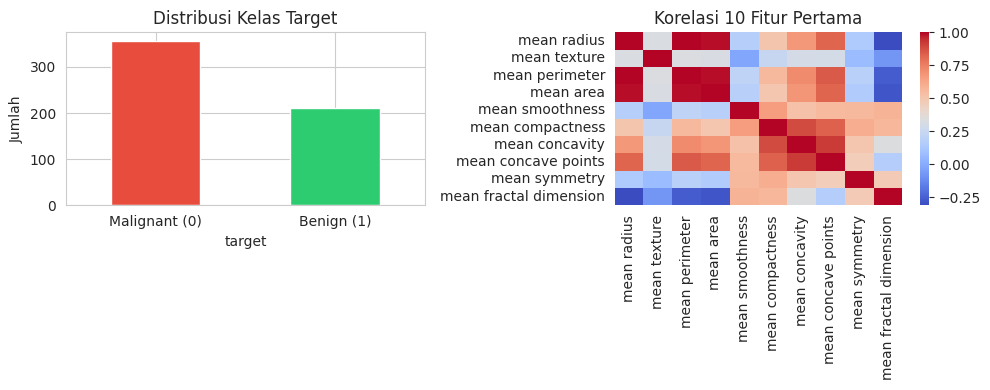

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
y.value_counts().plot(kind="bar", ax=ax[0], color=["#e74c3c", "#2ecc71"])
ax[0].set_title("Distribusi Kelas Target")
ax[0].set_xticklabels(["Malignant (0)", "Benign (1)"], rotation=0)
ax[0].set_ylabel("Jumlah")

sns.heatmap(X.iloc[:, :10].corr(), annot=False, cmap="coolwarm", ax=ax[1])
ax[1].set_title("Korelasi 10 Fitur Pertama")
plt.tight_layout()
plt.show()


## 3. Split Data Train-Test
Data dibagi 80% train dan 20% test dengan stratifikasi agar proporsi kelas tetap terjaga.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (455, 30)
Test shape : (114, 30)


## 4. Model 1 — Logistic Regression

In [5]:
logreg = LogisticRegression(max_iter=5000, random_state=42)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_logreg)
prec_lr = precision_score(y_test, y_pred_logreg)
rec_lr = recall_score(y_test, y_pred_logreg)
f1_lr = f1_score(y_test, y_pred_logreg)

print("=== Logistic Regression ===")
print(f"Accuracy  : {acc_lr:.4f}")
print(f"Precision : {prec_lr:.4f}")
print(f"Recall    : {rec_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")


=== Logistic Regression ===
Accuracy  : 0.9649
Precision : 0.9595
Recall    : 0.9861
F1-Score  : 0.9726


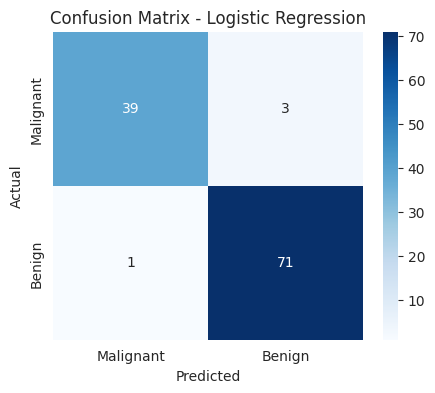

In [6]:
cm_lr = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 5. Model 2 — Decision Tree

In [7]:
dtree = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree.fit(X_train, y_train)
y_pred_dtree = dtree.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dtree)
prec_dt = precision_score(y_test, y_pred_dtree)
rec_dt = recall_score(y_test, y_pred_dtree)
f1_dt = f1_score(y_test, y_pred_dtree)

print("=== Decision Tree ===")
print(f"Accuracy  : {acc_dt:.4f}")
print(f"Precision : {prec_dt:.4f}")
print(f"Recall    : {rec_dt:.4f}")
print(f"F1-Score  : {f1_dt:.4f}")


=== Decision Tree ===
Accuracy  : 0.9386
Precision : 0.9577
Recall    : 0.9444
F1-Score  : 0.9510


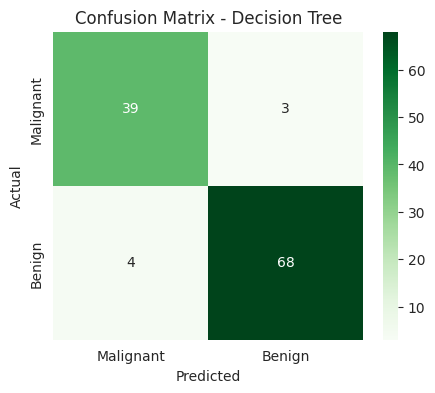

In [8]:
cm_dt = confusion_matrix(y_test, y_pred_dtree)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


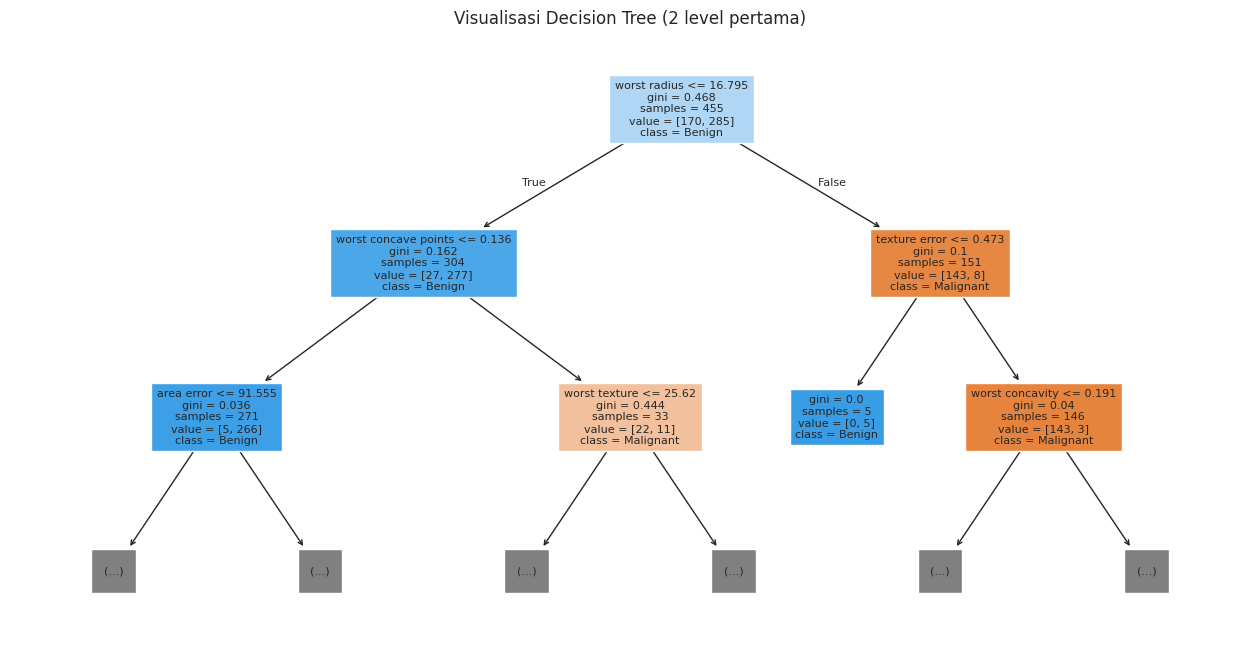

In [9]:
plt.figure(figsize=(16, 8))
plot_tree(dtree, feature_names=data.feature_names, class_names=["Malignant", "Benign"],
          filled=True, max_depth=2, fontsize=8)
plt.title("Visualisasi Decision Tree (2 level pertama)")
plt.show()


## 6. Perbandingan Model

In [10]:
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [acc_lr, acc_dt],
    "Precision": [prec_lr, prec_dt],
    "Recall": [rec_lr, rec_dt],
    "F1-Score": [f1_lr, f1_dt]
})
summary


                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.964912   0.959459  0.986111  0.972603
1        Decision Tree  0.938596   0.957746  0.944444  0.951049

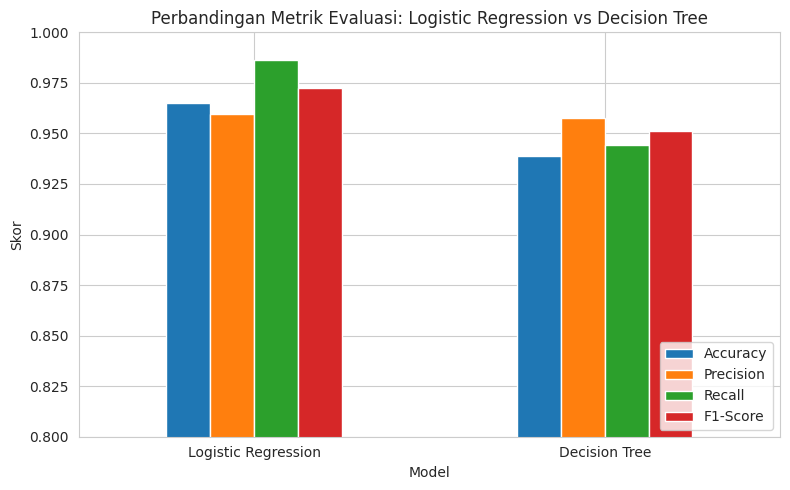

In [11]:
summary.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar", figsize=(8, 5), ylim=(0.8, 1.0)
)
plt.title("Perbandingan Metrik Evaluasi: Logistic Regression vs Decision Tree")
plt.ylabel("Skor")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 7. Interpretasi Singkat

Pada kasus **deteksi kanker payudara** ini, kelas positif yang paling kritis adalah **malignant (ganas)**. Kesalahan yang paling berbahaya adalah **False Negative** — pasien yang sebenarnya menderita kanker ganas tetapi diprediksi jinak, karena bisa menyebabkan keterlambatan penanganan medis.

Oleh karena itu:
- **Recall** (terutama untuk kelas malignant) adalah metrik yang **paling relevan**, karena mengukur seberapa baik model menangkap seluruh kasus positif (ganas) yang sebenarnya ada, meminimalkan False Negative.
- **Accuracy** saja kurang cukup diandalkan bila digunakan sendirian, karena tidak membedakan jenis kesalahan (False Positive vs False Negative) dan bisa terlihat tinggi meskipun model sering melewatkan kasus ganas.
- **Precision** tetap penting untuk menghindari terlalu banyak False Positive (pasien sehat didiagnosis ganas) yang menyebabkan kecemasan dan biaya pemeriksaan lanjutan yang tidak perlu.
- **F1-Score** berguna sebagai ringkasan tunggal yang menyeimbangkan precision dan recall, terutama saat membandingkan beberapa model sekaligus seperti pada notebook ini.

Berdasarkan confusion matrix di atas, kedua model menunjukkan performa yang baik, namun perlu diperhatikan jumlah False Negative pada masing-masing model sebagai indikator utama kelayakan model untuk digunakan dalam konteks medis nyata.

## 8. Kesimpulan

**Apa yang dipelajari:**
Pada pertemuan ini saya mempelajari dua algoritma klasifikasi dasar, yaitu Logistic Regression dan Decision Tree, serta cara mengevaluasi model klasifikasi menggunakan Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score.

**Temuan utama:**
Kedua model menghasilkan performa yang tinggi pada dataset Breast Cancer Wisconsin, dengan Logistic Regression maupun Decision Tree sama-sama mampu mencapai accuracy dan F1-Score di atas 0.9. Confusion matrix membantu mengidentifikasi jenis kesalahan (False Positive vs False Negative) yang tidak terlihat hanya dari accuracy saja.

**Keterbatasan / pertanyaan yang muncul:**
- Decision Tree dengan `max_depth` yang lebih besar berpotensi overfitting; belum dieksplorasi teknik pruning atau cross-validation untuk memastikan generalisasi model.
- Bagaimana performa kedua model ini jika diterapkan pada dataset yang jauh lebih tidak seimbang (imbalanced) dibanding Breast Cancer Wisconsin ini? Topik ini akan dibahas lebih lanjut pada Pertemuan 10.